# Face ROI + ITA + adaptive light preprocessing pipeline

Цей ноутбук переписаний у більш модульному стилі:

- без дублювання `detector` / ROI / CLAHE логіки
- з reusable-функціями для обробки одного зображення або всього датасету
- з окремими візуалізаціями:
  - ROI / маски / контури
  - original vs clean ROI
  - original vs CLAHE
  - original vs overexposure correction
- з двома гілками корекції освітлення:
  - **dark / underexposed** → `CLAHE`
  - **very bright / overexposed** → корекція через **L-канал у CIELAB**

За замовчуванням для дуже світлих фото використовується метод `lab_l`, бо він акуратніше працює зі шкірою, ніж глобальна HSV-корекція.


In [ ]:

import os
import pickle
from dataclasses import dataclass
from pathlib import Path

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


MODEL_PATH = "models/face_landmarker.task"


@dataclass
class FaceRoiConfig:
    eye_dilate_ksize: int = 9
    lips_dilate_ksize: int = 11
    brow_dilate_ksize: int = 9
    clip_limit: float = 2.0
    tile_grid_size: tuple = (8, 8)
    ita_threshold: float = -10.0
    clahe_mode: str = "below"   # "below" | "above" | "always" | "never"

    # Overexposure handling
    high_ita_threshold: float = 45.0
    enable_overexposure_fix: bool = True
    overexposure_target: str = "roi"   # "full" | "roi"
    overexposure_method: str = "lab_l"  # "lab_l" | "hsv_mild"

    # LAB L-channel correction params
    overexposure_lab_strength: float = 0.7
    overexposure_lab_compression: float = 1.35
    overexposure_lab_blend: float = 0.6

    # HSV mild correction params (optional fallback / comparison)
    overexposure_saturation_scale: float = 0.88
    overexposure_value_gamma: float = 1.08
    overexposure_blend: float = 0.35


FACE_OVAL_IDX = [
    10,338,297,332,284,251,389,356,454,323,
    361,288,397,365,379,378,400,377,152,
    148,176,149,150,136,172,58,132,93,
    234,127,162,21,54,103,67,109
]

OUTER_LIPS_IDX = [
    61,146,91,181,84,17,314,405,321,375,291,
    409,270,269,267,0,37,39,40,185
]

LEFT_EYE_IDX = [33,160,158,133,153,144]
RIGHT_EYE_IDX = [362,385,387,263,373,380]

LEFT_EYEBROW_IDX = [70, 63, 105, 66, 107, 55, 65, 52, 53, 46]
RIGHT_EYEBROW_IDX = [336, 296, 334, 293, 300, 285, 295, 282, 283, 276]


FEATURE_POLYGONS = {
    "face": FACE_OVAL_IDX,
    "lips": OUTER_LIPS_IDX,
    "left_eye": LEFT_EYE_IDX,
    "right_eye": RIGHT_EYE_IDX,
    "left_brow": LEFT_EYEBROW_IDX,
    "right_brow": RIGHT_EYEBROW_IDX,
}


def create_face_landmarker(model_path=MODEL_PATH, num_faces=1):
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=num_faces,
    )
    return vision.FaceLandmarker.create_from_options(options)


detector = create_face_landmarker(MODEL_PATH)

img_dir = Path("data\images_wrinkles")
mask_dir = Path("data\manual_wrinkle_masks")
image_paths = sorted(img_dir.glob("*.png"))

pairs = []

for img_path in image_paths:
    mask_path = mask_dir / img_path.name
    
    if mask_path.exists():
        pairs.append((img_path, mask_path))
    else:
        print(f"⚠ Mask not found for {img_path.name}")

print(f"Recovered {len(pairs)} pairs successfully.")
pairs[:3]

<>:96: SyntaxWarning: invalid escape sequence '\i'
<>:97: SyntaxWarning: invalid escape sequence '\m'
<>:96: SyntaxWarning: invalid escape sequence '\i'
<>:97: SyntaxWarning: invalid escape sequence '\m'
C:\Users\mpele\AppData\Local\Temp\ipykernel_1696\2577145440.py:96: SyntaxWarning: invalid escape sequence '\i'
  img_dir = Path("data\images_wrinkles")
C:\Users\mpele\AppData\Local\Temp\ipykernel_1696\2577145440.py:97: SyntaxWarning: invalid escape sequence '\m'
  mask_dir = Path("data\manual_wrinkle_masks")
c:\Users\mpele\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Recovered 1000 pairs successfully.


[(WindowsPath('data/images_wrinkles/00001.png'),
  WindowsPath('data/manual_wrinkle_masks/00001.png')),
 (WindowsPath('data/images_wrinkles/00011.png'),
  WindowsPath('data/manual_wrinkle_masks/00011.png')),
 (WindowsPath('data/images_wrinkles/00016.png'),
  WindowsPath('data/manual_wrinkle_masks/00016.png'))]

In [2]:

def read_rgb_image(image_or_path):
    if isinstance(image_or_path, (str, Path)):
        return np.array(Image.open(image_or_path).convert("RGB"))
    return np.asarray(image_or_path).copy()


def detect_face_landmarks(img_rgb, detector=detector):
    h, w = img_rgb.shape[:2]
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = detector.detect(mp_image)

    if not result.face_landmarks:
        return None, h, w
    return result.face_landmarks[0], h, w


def landmarks_to_polygon(face_landmarks, indices, h, w):
    pts = []
    for idx in indices:
        lm = face_landmarks[idx]
        pts.append([int(lm.x * w), int(lm.y * h)])
    return np.array(pts, dtype=np.int32)


def polygon_to_mask(img_shape, polygon):
    mask = np.zeros(img_shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [polygon], 1)
    return mask


def maybe_convex_hull(polygon):
    return cv2.convexHull(polygon) if len(polygon) >= 3 else polygon


def dilate_mask(mask, ksize):
    if ksize is None or ksize <= 1:
        return mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    return cv2.dilate(mask, kernel, iterations=1)


def overlay_mask(img_rgb, mask, color=(255, 0, 0), alpha=0.35):
    out = img_rgb.copy()
    color_img = np.zeros_like(out)
    color_img[..., 0] = color[0]
    color_img[..., 1] = color[1]
    color_img[..., 2] = color[2]

    mask_3d = (mask > 0)[..., None]
    blended = ((1 - alpha) * out + alpha * color_img).astype(np.uint8)
    out[mask_3d.squeeze(-1)] = blended[mask_3d.squeeze(-1)]
    return out


def draw_polygon(img_rgb, polygon, color=(0, 255, 0), thickness=2):
    out = img_rgb.copy()
    cv2.polylines(out, [polygon], isClosed=True, color=color, thickness=thickness)
    return out


def apply_mask_to_image(img_rgb, mask, fill_value=0):
    out = img_rgb.copy()
    out[mask == 0] = fill_value
    return out


def build_feature_polygons(face_landmarks, h, w):
    polygons = {}
    for name, indices in FEATURE_POLYGONS.items():
        poly = landmarks_to_polygon(face_landmarks, indices, h, w)
        if name != "face":
            poly = maybe_convex_hull(poly)
        polygons[name] = poly
    return polygons


def build_feature_masks(img_shape, polygons, cfg):
    masks = {}
    masks["face"] = polygon_to_mask(img_shape, polygons["face"])
    masks["lips"] = dilate_mask(polygon_to_mask(img_shape, polygons["lips"]), cfg.lips_dilate_ksize)
    masks["left_eye"] = dilate_mask(polygon_to_mask(img_shape, polygons["left_eye"]), cfg.eye_dilate_ksize)
    masks["right_eye"] = dilate_mask(polygon_to_mask(img_shape, polygons["right_eye"]), cfg.eye_dilate_ksize)
    masks["left_brow"] = dilate_mask(polygon_to_mask(img_shape, polygons["left_brow"]), cfg.brow_dilate_ksize)
    masks["right_brow"] = dilate_mask(polygon_to_mask(img_shape, polygons["right_brow"]), cfg.brow_dilate_ksize)

    masks["eyes"] = np.clip(masks["left_eye"] + masks["right_eye"], 0, 1).astype(np.uint8)
    masks["brows"] = np.clip(masks["left_brow"] + masks["right_brow"], 0, 1).astype(np.uint8)
    masks["excluded"] = np.clip(masks["lips"] + masks["eyes"] + masks["brows"], 0, 1).astype(np.uint8)
    masks["clean_roi"] = np.clip(masks["face"] - masks["excluded"], 0, 1).astype(np.uint8)
    return masks


def build_clean_face_roi(image_or_path, detector=detector, cfg=None):
    cfg = cfg or FaceRoiConfig()
    img_rgb = read_rgb_image(image_or_path)

    face_landmarks, h, w = detect_face_landmarks(img_rgb, detector=detector)
    if face_landmarks is None:
        return {
            "status": "no_face",
            "image": img_rgb,
        }

    polygons = build_feature_polygons(face_landmarks, h, w)
    masks = build_feature_masks(img_rgb.shape, polygons, cfg)

    clean_roi_only = apply_mask_to_image(img_rgb, masks["clean_roi"], fill_value=0)

    return {
        "status": "ok",
        "image": img_rgb,
        "clean_roi_only": clean_roi_only,
        "polygons": polygons,
        "masks": masks,
        "shape": (h, w),
    }


In [3]:

def compute_ita_from_mask(img_rgb, roi_mask, eps=1e-6):
    roi_mask = (roi_mask > 0).astype(np.uint8)
    if roi_mask.sum() == 0:
        return None

    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[..., 0] * (100.0 / 255.0)
    b = lab[..., 2] - 128.0

    L_roi = L[roi_mask > 0]
    b_roi = b[roi_mask > 0]
    b_roi = np.where(np.abs(b_roi) < eps, eps, b_roi)

    ita_vals = np.degrees(np.arctan((L_roi - 50.0) / b_roi))
    return float(np.mean(ita_vals))


def apply_clahe_rgb(img_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size,
    )
    l2 = clahe.apply(l)

    lab2 = cv2.merge((l2, a, b))
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)


def apply_clahe_on_roi(img_rgb, roi_mask, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe_full = apply_clahe_rgb(
        img_rgb,
        clip_limit=clip_limit,
        tile_grid_size=tile_grid_size,
    )
    out = img_rgb.copy()
    out[roi_mask > 0] = clahe_full[roi_mask > 0]
    return out


def apply_mild_overexposure_correction_rgb(
    img_rgb,
    saturation_scale=0.88,
    value_gamma=1.08,
    blend=0.35,
):
    """
    Mild correction for overexposed / washed-out images:
    - slightly reduces saturation
    - slightly compresses bright values via gamma on V channel
    - blends with original so the effect stays gentle
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)

    h = hsv[..., 0]
    s = hsv[..., 1]
    v = hsv[..., 2] / 255.0

    s2 = np.clip(s * saturation_scale, 0, 255)
    v2 = np.clip((v ** value_gamma) * 255.0, 0, 255)

    corrected_hsv = np.stack([h, s2, v2], axis=-1).astype(np.uint8)
    corrected_rgb = cv2.cvtColor(corrected_hsv, cv2.COLOR_HSV2RGB)

    blend = float(np.clip(blend, 0.0, 1.0))
    out = cv2.addWeighted(
        img_rgb.astype(np.uint8),
        1.0 - blend,
        corrected_rgb.astype(np.uint8),
        blend,
        0,
    )
    return out


def apply_mild_overexposure_correction_on_roi(
    img_rgb,
    roi_mask,
    saturation_scale=0.88,
    value_gamma=1.08,
    blend=0.35,
):
    corrected_full = apply_mild_overexposure_correction_rgb(
        img_rgb,
        saturation_scale=saturation_scale,
        value_gamma=value_gamma,
        blend=blend,
    )
    out = img_rgb.copy()
    out[roi_mask > 0] = corrected_full[roi_mask > 0]
    return out


def apply_lab_l_correction_rgb(
    img_rgb,
    strength=0.7,
    compression=1.35,
    blend=0.6,
):
    """
    Overexposure correction through LAB L-channel only.
    Works well for skin because it mainly changes lightness,
    while preserving chromatic channels (a, b).
    """
    strength = float(np.clip(strength, 0.0, 1.0))
    compression = max(float(compression), 1.0)
    blend = float(np.clip(blend, 0.0, 1.0))

    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[..., 0]
    A = lab[..., 1]
    B = lab[..., 2]

    L_norm = L / 255.0
    L_compressed = np.power(L_norm, compression)
    L_new = (1.0 - strength) * L_norm + strength * L_compressed
    L_new = np.clip(L_new * 255.0, 0, 255).astype(np.uint8)

    lab_new = cv2.merge([
        L_new,
        A.astype(np.uint8),
        B.astype(np.uint8),
    ])
    corrected = cv2.cvtColor(lab_new, cv2.COLOR_LAB2RGB)

    out = cv2.addWeighted(
        img_rgb.astype(np.uint8),
        1.0 - blend,
        corrected.astype(np.uint8),
        blend,
        0,
    )
    return out


def apply_lab_l_correction_on_roi(
    img_rgb,
    roi_mask,
    strength=0.7,
    compression=1.35,
    blend=0.6,
):
    corrected_full = apply_lab_l_correction_rgb(
        img_rgb,
        strength=strength,
        compression=compression,
        blend=blend,
    )
    out = img_rgb.copy()
    out[roi_mask > 0] = corrected_full[roi_mask > 0]
    return out


def apply_overexposure_fix(
    img_rgb,
    roi_mask=None,
    method="lab_l",
    target="roi",
    cfg=None,
):
    cfg = cfg or FaceRoiConfig()

    if method == "lab_l":
        if target == "roi" and roi_mask is not None:
            return apply_lab_l_correction_on_roi(
                img_rgb,
                roi_mask,
                strength=cfg.overexposure_lab_strength,
                compression=cfg.overexposure_lab_compression,
                blend=cfg.overexposure_lab_blend,
            )
        return apply_lab_l_correction_rgb(
            img_rgb,
            strength=cfg.overexposure_lab_strength,
            compression=cfg.overexposure_lab_compression,
            blend=cfg.overexposure_lab_blend,
        )

    if method == "hsv_mild":
        if target == "roi" and roi_mask is not None:
            return apply_mild_overexposure_correction_on_roi(
                img_rgb,
                roi_mask,
                saturation_scale=cfg.overexposure_saturation_scale,
                value_gamma=cfg.overexposure_value_gamma,
                blend=cfg.overexposure_blend,
            )
        return apply_mild_overexposure_correction_rgb(
            img_rgb,
            saturation_scale=cfg.overexposure_saturation_scale,
            value_gamma=cfg.overexposure_value_gamma,
            blend=cfg.overexposure_blend,
        )

    raise ValueError("method must be one of: 'lab_l', 'hsv_mild'")


def should_apply_overexposure_fix(ita, high_threshold=45.0, enabled=True):
    if not enabled or ita is None:
        return False
    return ita > high_threshold


def should_apply_clahe(ita, threshold=-10, mode="below"):
    if mode == "always":
        return True
    if mode == "never":
        return False
    if ita is None:
        return False
    if mode == "below":
        return ita < threshold
    if mode == "above":
        return ita > threshold
    raise ValueError("mode must be one of: 'below', 'above', 'always', 'never'")


def process_face_image(
    image_or_path,
    detector=detector,
    cfg=None,
    clahe_target="full",  # "full" | "roi"
):
    cfg = cfg or FaceRoiConfig()
    roi_res = build_clean_face_roi(image_or_path, detector=detector, cfg=cfg)

    if roi_res["status"] != "ok":
        return {
            "status": roi_res["status"],
            "image": roi_res["image"],
            "ita": None,
            "action": "keep",
            "output_image": roi_res["image"],
            "roi": roi_res,
        }

    img_rgb = roi_res["image"]
    roi_mask = roi_res["masks"]["clean_roi"]
    ita = compute_ita_from_mask(img_rgb, roi_mask)

    need_clahe = should_apply_clahe(
        ita=ita,
        threshold=cfg.ita_threshold,
        mode=cfg.clahe_mode,
    )
    need_overexposure_fix = should_apply_overexposure_fix(
        ita=ita,
        high_threshold=cfg.high_ita_threshold,
        enabled=cfg.enable_overexposure_fix,
    )

    if need_clahe:
        if clahe_target == "roi":
            output_image = apply_clahe_on_roi(
                img_rgb,
                roi_mask,
                clip_limit=cfg.clip_limit,
                tile_grid_size=cfg.tile_grid_size,
            )
        else:
            output_image = apply_clahe_rgb(
                img_rgb,
                clip_limit=cfg.clip_limit,
                tile_grid_size=cfg.tile_grid_size,
            )
        action = "clahe"

    elif need_overexposure_fix:
        output_image = apply_overexposure_fix(
            img_rgb,
            roi_mask=roi_mask,
            method=cfg.overexposure_method,
            target=cfg.overexposure_target,
            cfg=cfg,
        )
        action = f"overexposure_fix_{cfg.overexposure_method}"

    else:
        output_image = img_rgb
        action = "keep"

    return {
        "status": "ok",
        "image": img_rgb,
        "ita": ita,
        "action": action,
        "output_image": output_image,
        "roi": roi_res,
        "need_clahe": need_clahe,
        "need_overexposure_fix": need_overexposure_fix,
    }


def compute_face_ita(image_or_path, detector=detector, cfg=None):
    cfg = cfg or FaceRoiConfig()
    roi_res = build_clean_face_roi(image_or_path, detector=detector, cfg=cfg)

    if roi_res["status"] != "ok":
        return {
            "img_path": str(image_or_path),
            "ita": None,
            "status": roi_res["status"],
        }

    ita = compute_ita_from_mask(
        roi_res["image"],
        roi_res["masks"]["clean_roi"],
    )
    return {
        "img_path": str(image_or_path),
        "ita": ita,
        "status": "ok" if ita is not None else "empty_roi",
    }


In [11]:

def visualize_roi_debug(image_or_path, detector=detector, cfg=None, alpha=0.35, figsize=(18, 10)):
    cfg = cfg or FaceRoiConfig()
    res = build_clean_face_roi(image_or_path, detector=detector, cfg=cfg)

    if res["status"] != "ok":
        print("Face not detected")
        plt.figure(figsize=(6, 6))
        plt.imshow(res["image"])
        plt.title("Original (no face detected)")
        plt.axis("off")
        plt.show()
        return res

    img = res["image"]
    masks = res["masks"]
    polygons = res["polygons"]

    contour_img = img.copy()
    contour_colors = {
        "face": (0, 255, 0),
        "lips": (255, 0, 0),
        "left_eye": (255, 255, 0),
        "right_eye": (255, 255, 0),
        "left_brow": (255, 0, 255),
        "right_brow": (255, 0, 255),
    }
    for name, poly in polygons.items():
        contour_img = draw_polygon(contour_img, poly, color=contour_colors.get(name, (0, 255, 0)))

    overlays = {
        "Face overlay": overlay_mask(img, masks["face"], color=(0, 255, 0), alpha=alpha),
        "Excluded overlay": overlay_mask(img, masks["excluded"], color=(255, 0, 0), alpha=alpha),
        "Clean ROI overlay": overlay_mask(img, masks["clean_roi"], color=(0, 0, 255), alpha=alpha),
    }

    fig, axes = plt.subplots(2, 4, figsize=figsize)

    panels = [
        ("Original", img),
        ("Face mask", masks["face"]),
        ("Excluded mask", masks["excluded"]),
        ("Clean ROI mask", masks["clean_roi"]),
        ("Contours", contour_img),
        ("Eyes mask", masks["eyes"]),
        ("Brows mask", masks["brows"]),
        ("Lips mask", masks["lips"]),
    ]

    for ax, (title, panel) in zip(axes.ravel(), panels):
        if panel.ndim == 2:
            ax.imshow(panel, cmap="gray")
        else:
            ax.imshow(panel)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    extra_panels = [
        ("Face overlay", overlays["Face overlay"]),
        ("Excluded overlay", overlays["Excluded overlay"]),
        ("Clean ROI overlay", overlays["Clean ROI overlay"]),
        ("Clean ROI only", res["clean_roi_only"]),
    ]
    for ax, (title, panel) in zip(axes, extra_panels):
        ax.imshow(panel)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    return res


def visualize_clahe_comparison(
    image_or_path,
    detector=detector,
    cfg=None,
    show_roi_debug=True,
    figsize=(18, 9),
):
    cfg = cfg or FaceRoiConfig()
    proc_full = process_face_image(image_or_path, detector=detector, cfg=cfg, clahe_target="full")
    proc_roi = process_face_image(image_or_path, detector=detector, cfg=cfg, clahe_target="roi")

    img = proc_full["image"]
    roi_res = proc_full["roi"]

    if roi_res["status"] != "ok":
        print("Face not detected")
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title("Original (no face detected)")
        plt.axis("off")
        plt.show()
        return proc_full, proc_roi

    roi_mask = roi_res["masks"]["clean_roi"]
    clean_roi_only = roi_res["clean_roi_only"]
    clahe_full = apply_clahe_rgb(img, clip_limit=cfg.clip_limit, tile_grid_size=cfg.tile_grid_size)
    clahe_roi = apply_clahe_on_roi(img, roi_mask, clip_limit=cfg.clip_limit, tile_grid_size=cfg.tile_grid_size)
    clean_roi_clahe_only = apply_mask_to_image(clahe_full, roi_mask, fill_value=0)

    fig, axes = plt.subplots(2, 3, figsize=figsize)

    panels = [
        ("Original", img),
        ("Clean ROI mask", roi_mask),
        ("Clean ROI only", clean_roi_only),
        ("CLAHE full image", clahe_full),
        ("CLAHE only on ROI", clahe_roi),
        ("CLAHE ROI only", clean_roi_clahe_only),
    ]

    for ax, (title, panel) in zip(axes.ravel(), panels):
        if panel.ndim == 2:
            ax.imshow(panel, cmap="gray")
        else:
            ax.imshow(panel)
        ax.set_title(title)
        ax.axis("off")

    ita_text = f"ITA = {proc_full['ita']:.2f}" if proc_full["ita"] is not None else "ITA = None"
    fig.suptitle(f"{ita_text} | action = {proc_full['action']} | mode = {cfg.clahe_mode}", fontsize=13)
    plt.tight_layout()
    plt.show()

    if show_roi_debug:
        _ = visualize_roi_debug(image_or_path, detector=detector, cfg=cfg)

    return proc_full, proc_roi




def visualize_exposure_correction_comparison(
    image_or_path,
    detector=detector,
    cfg=None,
    figsize=(18, 10),
):
    cfg = cfg or FaceRoiConfig()
    res = build_clean_face_roi(image_or_path, detector=detector, cfg=cfg)

    if res["status"] != "ok":
        print("Face not detected")
        plt.figure(figsize=(6, 6))
        plt.imshow(res["image"])
        plt.title("Original (no face detected)")
        plt.axis("off")
        plt.show()
        return res

    img = res["image"]
    roi_mask = res["masks"]["clean_roi"]
    roi_only = apply_mask_to_image(img, roi_mask, fill_value=0)

    lab_fix = apply_lab_l_correction_on_roi(
        img,
        roi_mask,
        strength=cfg.overexposure_lab_strength,
        compression=cfg.overexposure_lab_compression,
        blend=cfg.overexposure_lab_blend,
    )
    hsv_fix = apply_mild_overexposure_correction_on_roi(
        img,
        roi_mask,
        saturation_scale=cfg.overexposure_saturation_scale,
        value_gamma=cfg.overexposure_value_gamma,
        blend=cfg.overexposure_blend,
    )
    selected_fix = apply_overexposure_fix(
        img,
        roi_mask=roi_mask,
        method=cfg.overexposure_method,
        target=cfg.overexposure_target,
        cfg=cfg,
    )

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()

    panels = [
        ("Original", img),
        ("Clean ROI mask", roi_mask),
        ("Clean ROI only", roi_only),
        ("LAB L fix on ROI", lab_fix),
        ("HSV mild fix on ROI", hsv_fix),
        (f"Selected: {cfg.overexposure_method}", selected_fix),
    ]

    for ax, (title, panel) in zip(axes, panels):
        if panel.ndim == 2:
            ax.imshow(panel, cmap="gray")
        else:
            ax.imshow(panel)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "status": "ok",
        "image": img,
        "roi_mask": roi_mask,
        "lab_fix": lab_fix,
        "hsv_fix": hsv_fix,
        "selected_fix": selected_fix,
    }


def show_processed_examples(
    df,
    threshold,
    mode="below",
    n=8,
    ncols=4,
    near_delta=2.0,
    detector=detector,
    cfg=None,
    clahe_target="full",
    figsize=(11, 10),
):
    cfg = cfg or FaceRoiConfig()
    work_df = df[df["ita"].notna()].copy()

    if mode == "below":
        subset = work_df[work_df["ita"] < threshold].sort_values("ita", ascending=True)
    elif mode == "above":
        subset = work_df[work_df["ita"] > threshold].sort_values("ita", ascending=False)
    elif mode == "near":
        subset = work_df[np.abs(work_df["ita"] - threshold) <= near_delta].copy()
        subset["dist"] = np.abs(subset["ita"] - threshold)
        subset = subset.sort_values("dist", ascending=True)
    else:
        raise ValueError("mode must be one of: below, above, near")

    subset = subset.head(n)

    if len(subset) == 0:
        print("No images found for this condition.")
        return

    nrows = int(np.ceil(len(subset) / ncols))
    fig, axes = plt.subplots(nrows * 2, ncols, figsize=figsize)
    axes = np.atleast_2d(axes)

    for ax in axes.ravel():
        ax.axis("off")

    for idx, (_, row) in enumerate(subset.iterrows()):
        proc = process_face_image(row["img_path"], detector=detector, cfg=cfg, clahe_target=clahe_target)
        r = idx // ncols
        c = idx % ncols

        axes[2 * r, c].imshow(proc["image"])
        # axes[2 * r, c].set_title(f"Orig | ITA={row['ita']:.2f}")
        axes[2 * r, c].set_title(f"Original image")

        axes[2 * r, c].axis("off")

        axes[2 * r + 1, c].imshow(proc["output_image"])
        axes[2 * r + 1, c].set_title(f"Processed | {proc['action']}")
        axes[2 * r + 1, c].axis("off")

    plt.tight_layout()
    plt.show()


In [5]:

def collect_ita_stats_from_pairs(pairs, detector=detector, cfg=None, verbose=True):
    cfg = cfg or FaceRoiConfig()
    rows = []
    iterator = tqdm(pairs, desc="Computing ITA") if verbose else pairs

    for img_path, _ in iterator:
        rows.append(compute_face_ita(img_path, detector=detector, cfg=cfg))

    return pd.DataFrame(rows)


def plot_ita_distribution(df, bins=30):
    vals = df.loc[df["ita"].notna(), "ita"].values
    if len(vals) == 0:
        print("No valid ITA values")
        return

    plt.figure(figsize=(8, 5))
    plt.hist(vals, bins=bins)
    plt.title("ITA distribution")
    plt.xlabel("ITA")
    plt.ylabel("Count")
    plt.grid(alpha=0.25)
    plt.show()

    print("Count:", len(vals))
    print("Min  :", np.min(vals))
    print("Max  :", np.max(vals))
    print("Mean :", np.mean(vals))
    print("Std  :", np.std(vals))
    print("Q10  :", np.percentile(vals, 10))
    print("Q25  :", np.percentile(vals, 25))
    print("Q50  :", np.percentile(vals, 50))
    print("Q75  :", np.percentile(vals, 75))
    print("Q90  :", np.percentile(vals, 90))


def build_preprocessed_dataset(
    pairs,
    output_dir,
    detector=detector,
    cfg=None,
    clahe_target="full",
    save_csv=True,
    image_subdir="images_wrinkles_preprocess",
):
    cfg = cfg or FaceRoiConfig()
    save_dir = os.path.join(output_dir, image_subdir)
    os.makedirs(save_dir, exist_ok=True)

    rows = []
    for img_path, _ in tqdm(pairs, desc="Processing images"):
        proc = process_face_image(
            img_path,
            detector=detector,
            cfg=cfg,
            clahe_target=clahe_target,
        )

        out_img = proc["output_image"]
        fname = os.path.basename(img_path)
        save_path = os.path.join(save_dir, fname)

        Image.fromarray(out_img).save(save_path, quality=95)

        rows.append({
            "orig_path": img_path,
            "saved_path": save_path,
            "ita": proc["ita"],
            "status": proc["status"],
            "action": proc["action"],
        })

    df = pd.DataFrame(rows)

    if save_csv:
        csv_path = os.path.join(output_dir, "preprocess_log.csv")
        df.to_csv(csv_path, index=False)
        print(f"Saved log: {csv_path}")

    return df


In [6]:

# === Example config ===
cfg = FaceRoiConfig(
    eye_dilate_ksize=9,
    lips_dilate_ksize=11,
    brow_dilate_ksize=9,
    clip_limit=1.5,
    tile_grid_size=(8, 8),

    # dark images
    ita_threshold=-10,
    clahe_mode="below",

    # bright / overexposed images
    high_ita_threshold=45,
    enable_overexposure_fix=True,
    overexposure_target="roi",
    overexposure_method="lab_l",

    # LAB L-channel correction
    overexposure_lab_strength=0.8,
    overexposure_lab_compression=1.5,
    overexposure_lab_blend=0.6,

    # optional HSV fallback / comparison
    overexposure_saturation_scale=0.88,
    overexposure_value_gamma=1.08,
    overexposure_blend=0.35,
)

print(cfg)


FaceRoiConfig(eye_dilate_ksize=9, lips_dilate_ksize=11, brow_dilate_ksize=9, clip_limit=1.5, tile_grid_size=(8, 8), ita_threshold=-10, clahe_mode='below', high_ita_threshold=45, enable_overexposure_fix=True, overexposure_target='roi', overexposure_method='lab_l', overexposure_lab_strength=0.8, overexposure_lab_compression=1.5, overexposure_lab_blend=0.6, overexposure_saturation_scale=0.88, overexposure_value_gamma=1.08, overexposure_blend=0.35)


In [7]:

# === Quick presets for LAB L-channel overexposure correction ===
lab_presets = {
    "safe": dict(overexposure_lab_strength=0.6, overexposure_lab_compression=1.25, overexposure_lab_blend=0.5),
    "balanced": dict(overexposure_lab_strength=0.7, overexposure_lab_compression=1.35, overexposure_lab_blend=0.6),
    "strong": dict(overexposure_lab_strength=0.9, overexposure_lab_compression=1.5, overexposure_lab_blend=0.7),
}
lab_presets


{'safe': {'overexposure_lab_strength': 0.6,
  'overexposure_lab_compression': 1.25,
  'overexposure_lab_blend': 0.5},
 'balanced': {'overexposure_lab_strength': 0.7,
  'overexposure_lab_compression': 1.35,
  'overexposure_lab_blend': 0.6},
 'strong': {'overexposure_lab_strength': 0.9,
  'overexposure_lab_compression': 1.5,
  'overexposure_lab_blend': 0.7}}

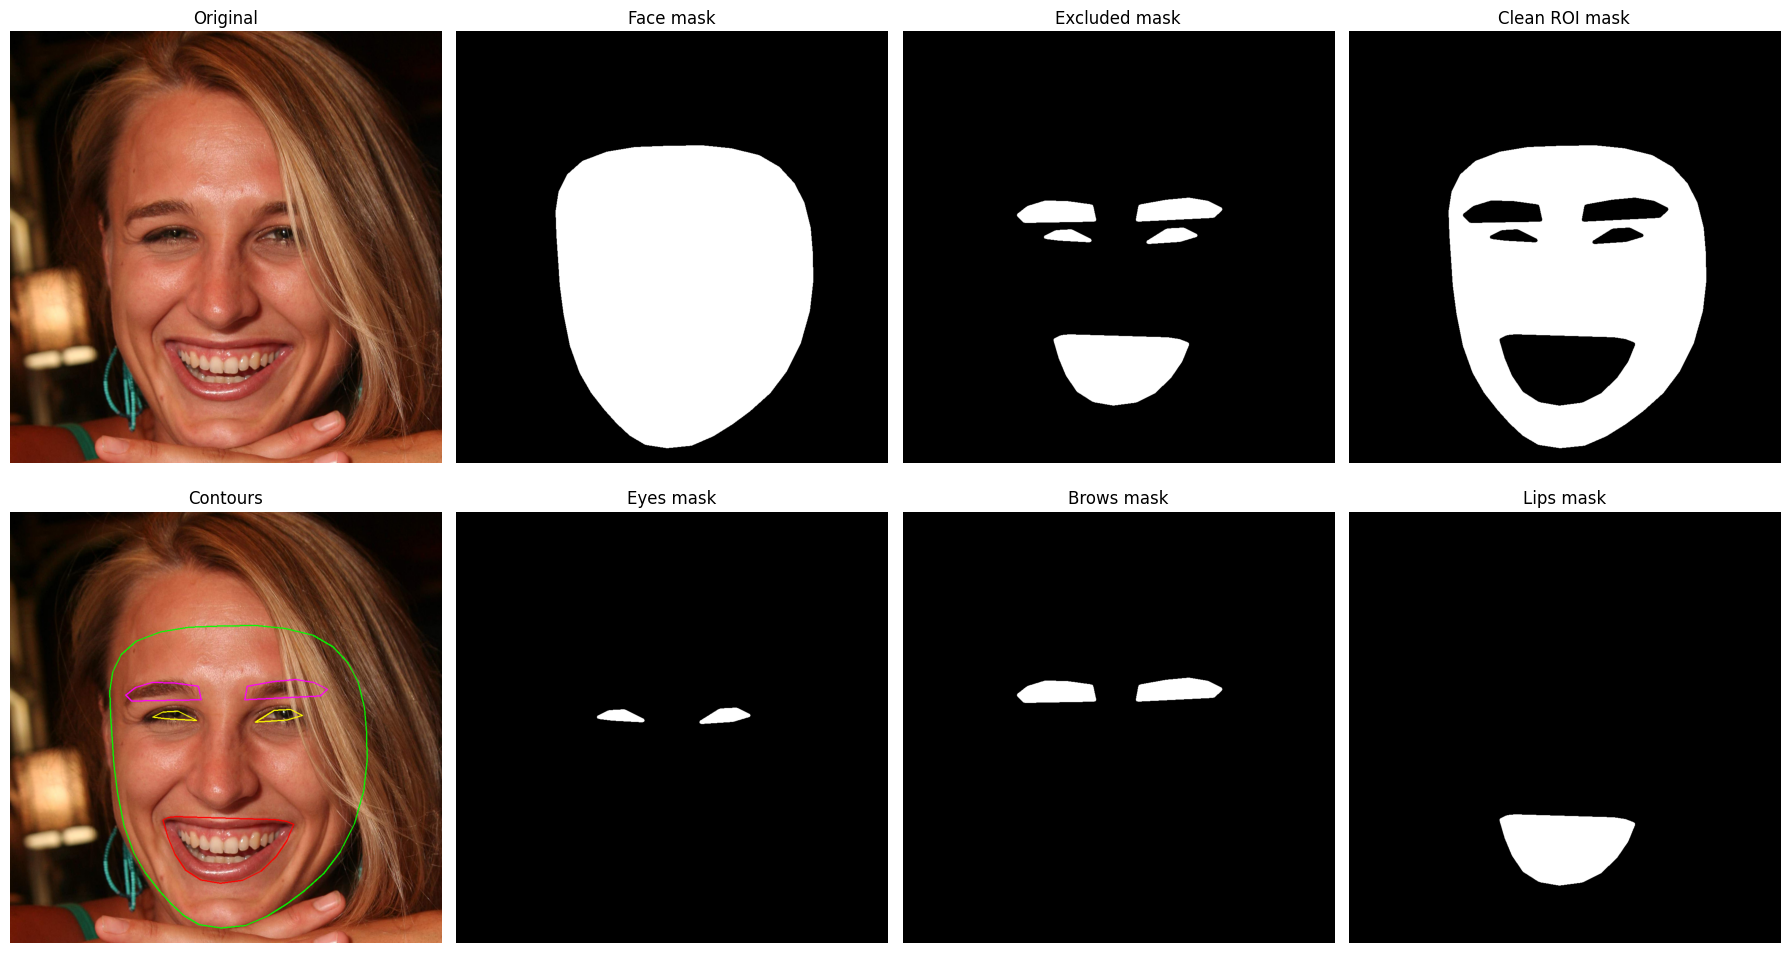

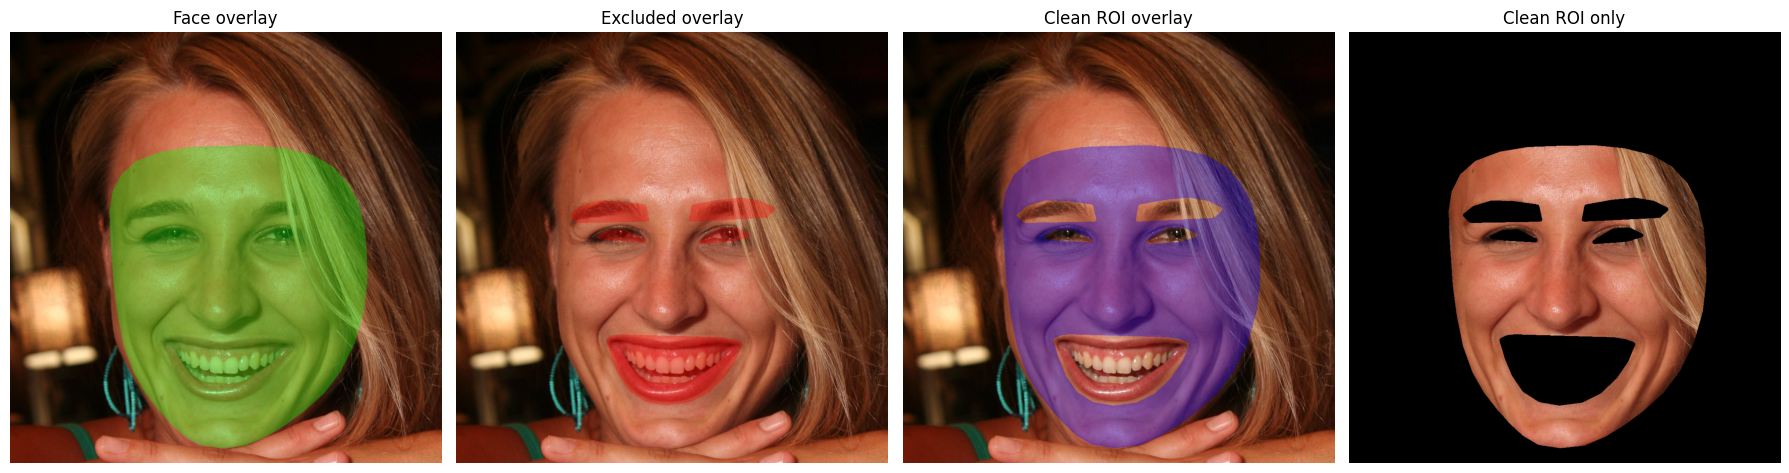

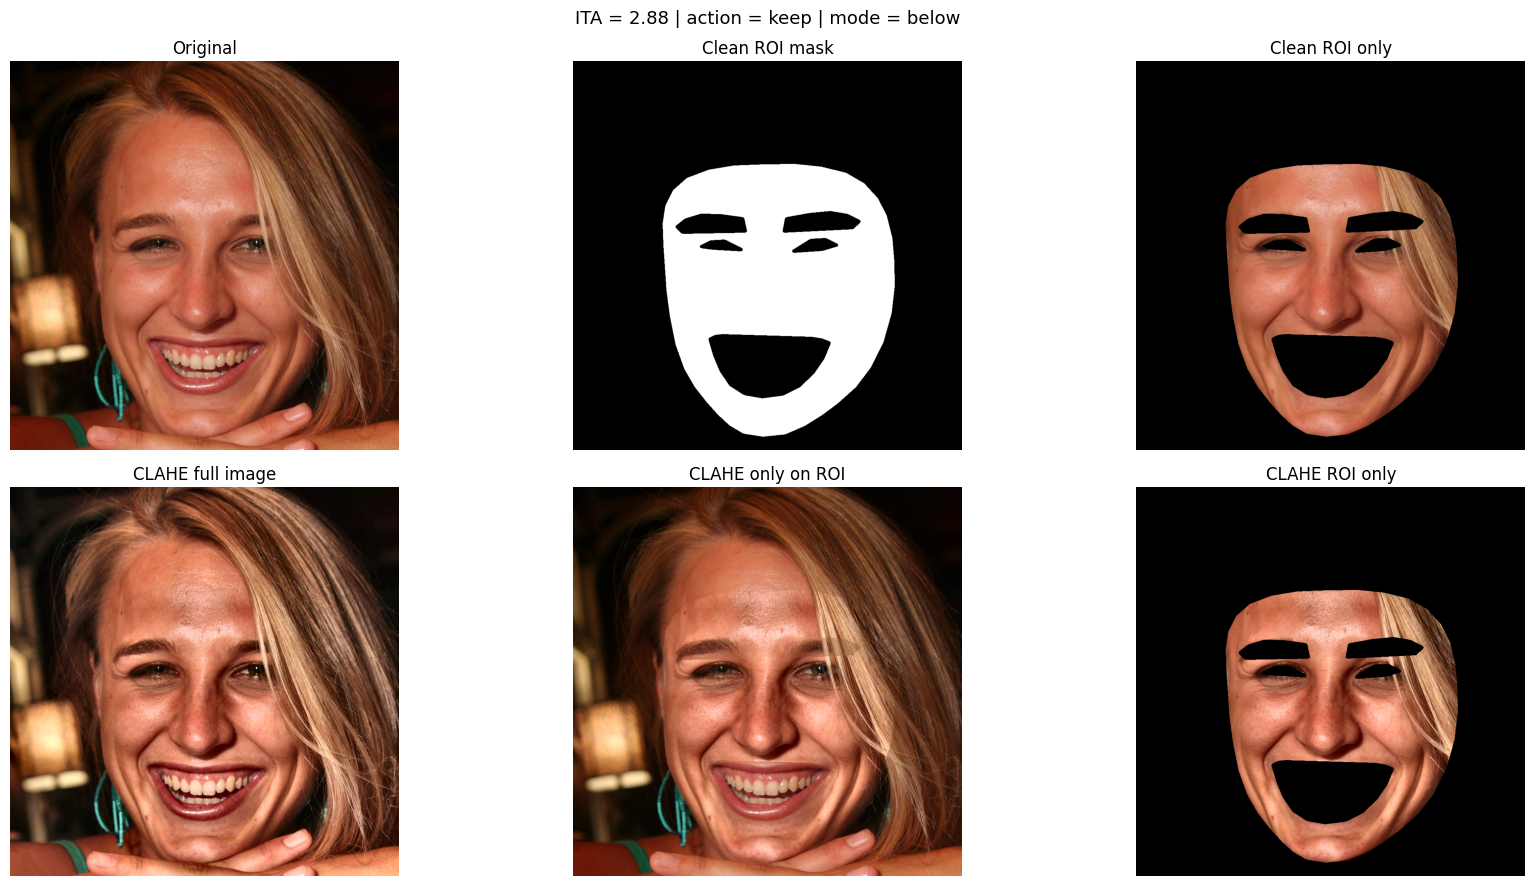

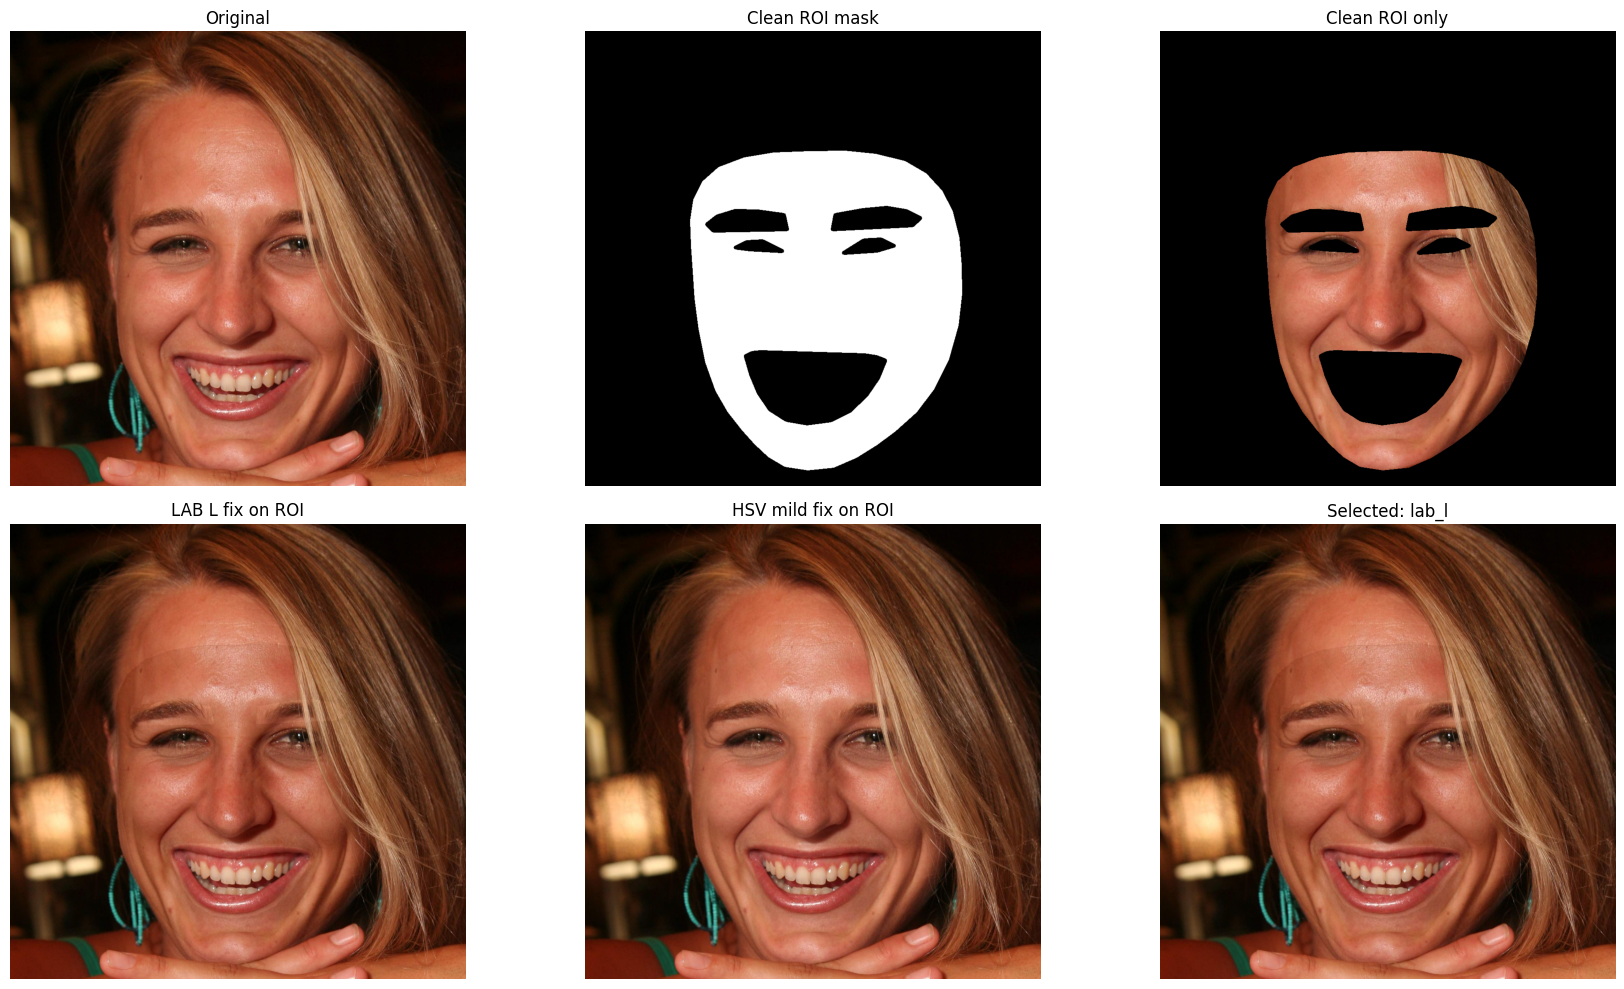

In [8]:

# === Example: visualize one sample ===
img_path, _ = pairs[0]
_ = visualize_roi_debug(img_path, detector=detector, cfg=cfg)
_ = visualize_clahe_comparison(img_path, detector=detector, cfg=cfg, show_roi_debug=False)
_ = visualize_exposure_correction_comparison(img_path, detector=detector, cfg=cfg)

Computing ITA: 100%|██████████| 1000/1000 [06:20<00:00,  2.63it/s]


,img_path,ita,status
0,data\images_wrinkles\00001.png,2.875249,ok
1,data\images_wrinkles\00011.png,29.264227,ok
2,data\images_wrinkles\00016.png,11.732812,ok
3,data\images_wrinkles\00017.png,-23.956024,ok
4,data\images_wrinkles\00018.png,37.255009,ok


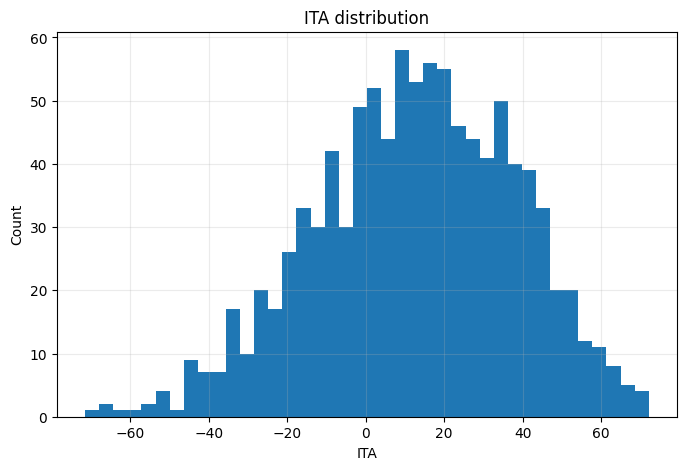

Count: 1000
Min  : -71.49076843261719
Max  : 72.14232635498047
Mean : 12.615644758820533
Std  : 25.63336283969948
Q10  : -21.02818946838379
Q25  : -4.272675275802612
Q50  : 13.611216068267822
Q75  : 31.75492286682129
Q90  : 44.54408874511719


In [7]:

# === Example: compute ITA stats ===
df_ita = collect_ita_stats_from_pairs(pairs, detector=detector, cfg=cfg)
display(df_ita.head())
plot_ita_distribution(df_ita, bins=40)

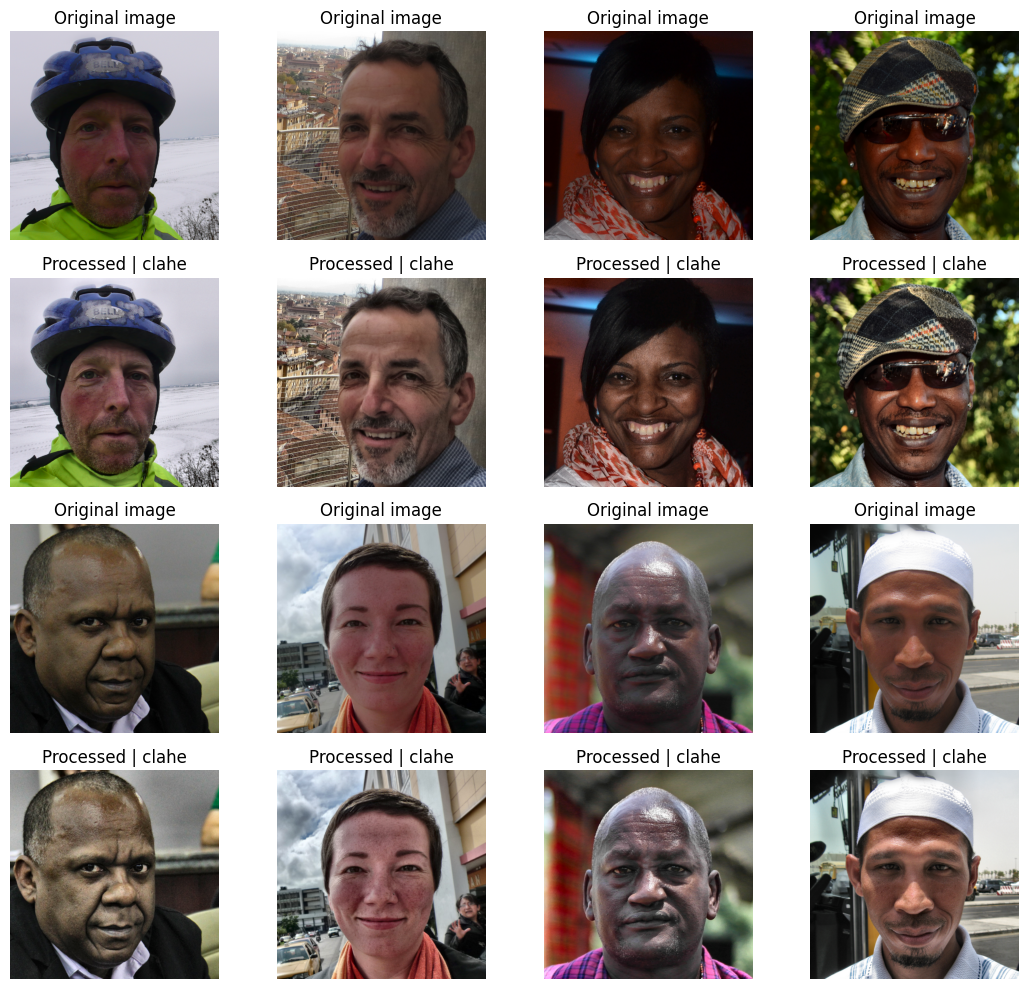

In [12]:

# === Example: show dark / bright examples with preprocessing ===
show_processed_examples(
        df=df_ita,
        threshold=cfg.ita_threshold,
        mode="below",
        n=8,    
        ncols=4,
        detector=detector,
        cfg=cfg,
        clahe_target="full",
    )

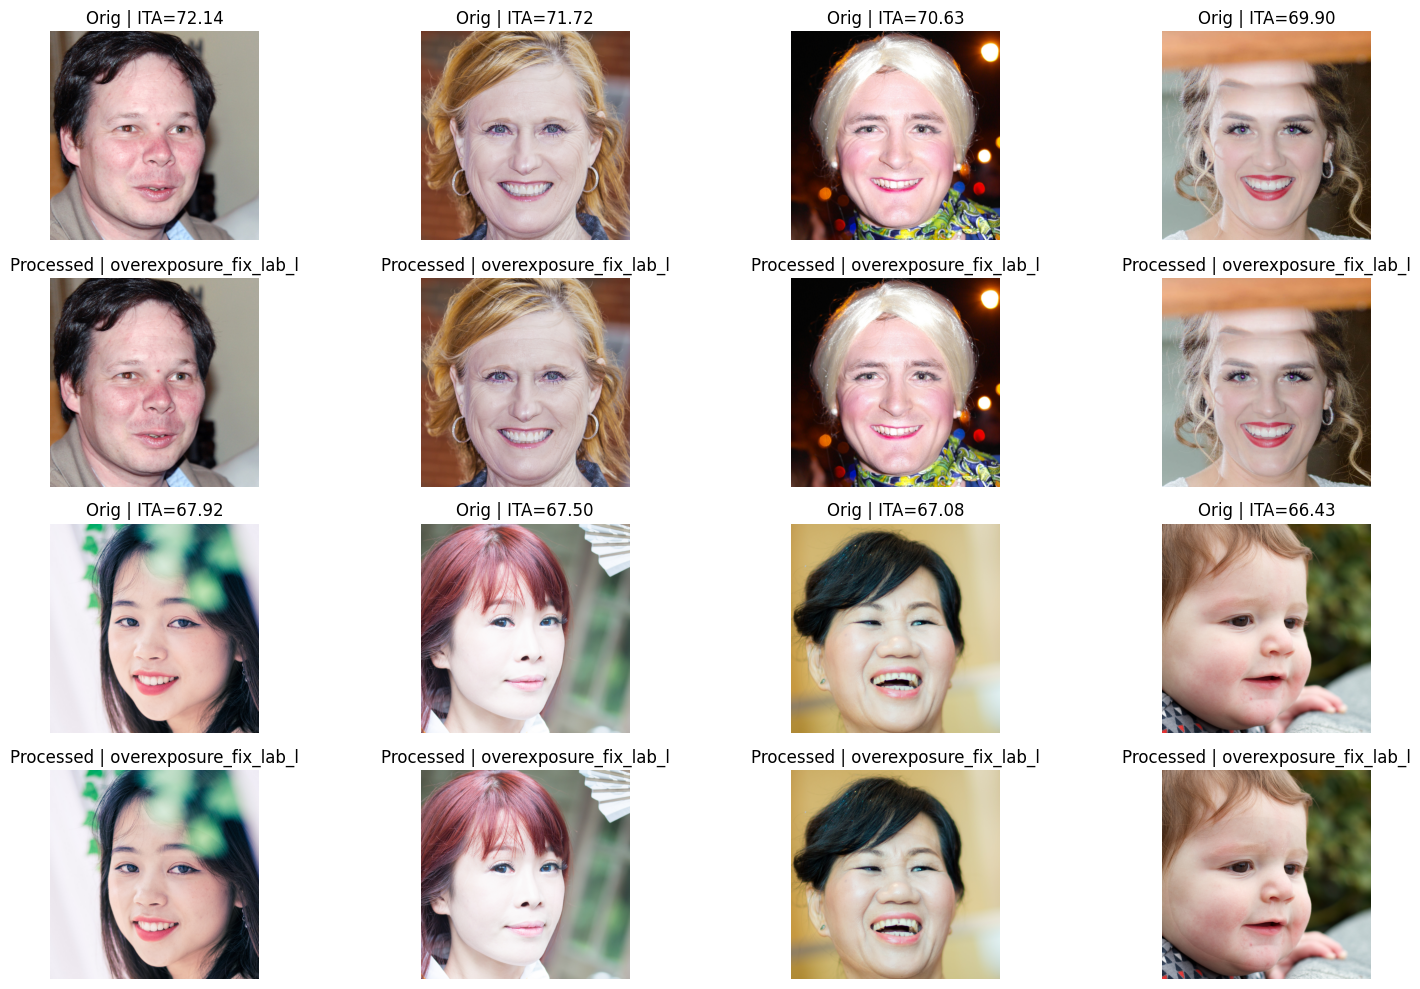

In [11]:
show_processed_examples(
    df=df_ita,
    threshold=cfg.high_ita_threshold,
    mode="above",          # 🔥 ключова зміна
    n=8,
    ncols=4,
    detector=detector,
    cfg=cfg,
)

In [ ]:

# === Example: build and save full preprocessed dataset ===
# df_new = build_preprocessed_dataset(
#     pairs=pairs,
#     output_dir="data_2",
#     detector=detector,
#     cfg=cfg,
#     clahe_target="full",   # or "roi"
#     save_csv=True,
# )
# display(df_new.head())
